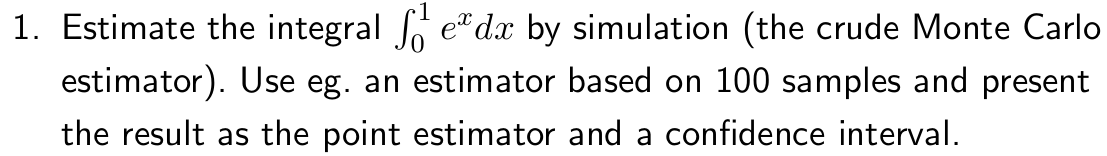

The general idea behind the crude Monte Carlo estimator is that we can write the integral as: 

$$\int_0^1e^xdx = E[e^{U}]$$

Where $U$ are uniformly generated random variables. We can thus generete values for $U$ and write $X_i = e^{U_i}$ and find the integtal as $E[X]$.

In [12]:
import numpy as np
from random import random

# Set seed
np.random.seed(0)

U = []
n = 100
for i in range(n):
    U.append(random())

U = np.array(U)
X = np.exp(U)

mean_X = np.mean(X)
print("Mean of X:", mean_X)

# Estimate confidence intervals
s2 = np.var(X, ddof=1)
alpha = 0.05
lower_bound = mean_X - 1.96 * np.sqrt(s2 / n)
upper_bound = mean_X + 1.96 * np.sqrt(s2 / n)
print(f"95% confidence interval for the mean of X: [{lower_bound}, {upper_bound}]")

# Theoretical mean of X
theoretical_mean_X = np.exp(1) - 1
print("Theoretical mean of X:", theoretical_mean_X)

Mean of X: 1.7659521231492312
95% confidence interval for the mean of X: [1.6605542211136157, 1.8713500251848467]
Theoretical mean of X: 1.718281828459045


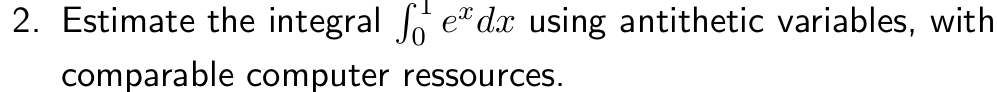

Using antithetic variables involves using the following expression: 

$$Y_i = \frac{e^{U_i}+e^{1-U_i}}{2}$$

Which can be shown to have $E[Y] = E[X]$ where $X$ is defined as in the previous method.

In [15]:
import numpy as np
from random import random

# Set seed
np.random.seed(0)

U = []
n = 100
for i in range(n):
    U.append(random())

U = np.array(U)
Y = (np.exp(U) + np.exp(1-U)) / 2

mean_Y = np.mean(Y)
print("Mean of Y:", mean_Y)

# Estimate confidence intervals
s2 = np.var(Y, ddof=1)
alpha = 0.05
lower_bound = mean_Y - 1.96 * np.sqrt(s2 / n)
upper_bound = mean_Y + 1.96 * np.sqrt(s2 / n)
print(f"95% confidence interval for the mean of Y: [{lower_bound}, {upper_bound}]")

# Theoretical mean of Y
theoretical_mean_Y = np.exp(1) - 1
print("Theoretical mean of Y:", theoretical_mean_Y)

Mean of Y: 1.7216105302431035
95% confidence interval for the mean of Y: [1.7083626910293228, 1.7348583694568842]
Theoretical mean of Y: 1.718281828459045


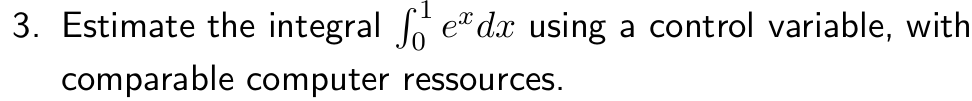

The idea behind covariates is to reformulate the stochastic variable by: 

$$Z_i = X_i + c(Y_i - E[Y])$$

To minimize variance we choose: 

$$c = \frac{-Cov(X,Y)}{Var(Y)}$$

For this specific case we choose $X_i = e^{U_i}$ and $Y_i = U_i$. 

In [27]:
import numpy as np
import random

# Set seed
np.random.seed(0)
random.seed(0)

U = []
n = 100
for i in range(n):
    U.append(random.random())

U = np.array(U)
X = np.exp(U)
Y = U
mean_Y = 0.5
c = -np.cov(X, Y)[0, 1] / np.var(Y)
Z = X + c * (Y - mean_Y)

mean_Z = np.mean(Z)
print("Mean of Z:", mean_Z)

# Estimate confidence intervals
s2 = np.var(Z, ddof=1)
alpha = 0.05
lower_bound = mean_Z - 1.96 * np.sqrt(s2 / n)
upper_bound = mean_Z + 1.96 * np.sqrt(s2 / n)
print(f"95% confidence interval for the mean of Z: [{lower_bound}, {upper_bound}]")

# Theoretical mean of Z
theoretical_mean_Z = np.exp(1) - 1
print("Theoretical mean of Z:", theoretical_mean_Z)

Mean of Z: 1.7055199178231613
95% confidence interval for the mean of Z: [1.6936509820046652, 1.7173888536416573]
Theoretical mean of Z: 1.718281828459045


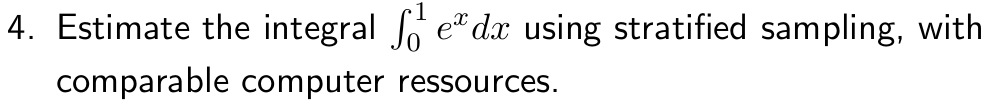

In stratified sampling we stratify the space of $U$ into subspaces and then perform the estimating using all of them. For the case of 10 stratified subspaces we have: 

$$W_i = \frac{e^{U_{i,1/10}} + e^{1/10 + U_{i,2/10}} + ... + e^{9/10+U_{i,10/10}}}{10}$$

In [ ]:
import numpy as np
import random

# Set seed
np.random.seed(0)
random.seed(0)

strata = 10

U = []
n = 100
for i in range(n):
    U.append(random.random())

U = np.array(U)
W = 0
for i in range(strata):   # 0..9
    W += np.exp(i/strata + U[i::strata])
W = W / strata

mean_X = np.mean(W)
print("Mean of X:", mean_X)

# Estimate confidence intervals
s2 = np.var(W, ddof=1)
alpha = 0.05
lower_bound = mean_X - 1.96 * np.sqrt(s2 / n)
upper_bound = mean_X + 1.96 * np.sqrt(s2 / n)
print(f"95% confidence interval for the mean of X: [{lower_bound}, {upper_bound}]")

# Theoretical mean of X
theoretical_mean_X = np.exp(1) - 1
print("Theoretical mean of X:", theoretical_mean_X)

0
1
2
3
4
5
6
7
8
9
Mean of X: 3.0605892281628053
95% confidence interval for the mean of X: [3.0143960989696623, 3.1067823573559483]
Theoretical mean of X: 1.718281828459045
